## Natural Language Processing with Scikit-Learn - Part 1

In [1]:
import nltk

In [2]:
# nltk.data.path.insert(0, r"D:\nltk_data")
# nltk.download("all", download_dir=r"D:\nltk_data")

In [3]:
# SMS Spam dataset

!curl https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip >> smsspamcollection.zip

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  44918   0  44918   0      0  25565      0           00:01          41433
100 198.6k   0 198.6k   0      0  83955      0           00:02          41433
100 198.6k   0 198.6k   0      0  83920      0           00:02          41433
100 198.6k   0 198.6k   0      0  83887      0           00:02          41433


In [4]:
!tar -xf smsspamcollection.zip 

In [5]:
!dir

 Volume in drive D is New Volume
 Volume Serial Number is 689C-9814

 Directory of D:\DataScience\data-science-for-everyone\natural-language-processing\nlp-with-scikit-learn

08/26/2026  08:39 PM    <DIR>          .
08/25/2026  10:01 AM    <DIR>          ..
08/26/2026  08:38 PM    <DIR>          .ipynb_checkpoints
08/26/2026  08:39 PM            13,595 natural_language_processing_with_pyspark_part_1.ipynb
04/18/2011  02:53 PM             5,868 readme
03/15/2011  10:36 PM           477,907 SMSSpamCollection
08/26/2026  08:39 PM           406,830 smsspamcollection.zip
               4 File(s)        904,200 bytes
               3 Dir(s)  323,347,959,808 bytes free


In [6]:
!powershell -command Get-Content SMSSpamCollection -head 10

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Aœ1.50 to rcv
ham	Even my brother is not like to speak with me. They treat me like aids patent.
ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
spam	WINNER!! As a valued network customer you have been selected to receivea Aœ900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
spam

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'text'])

In [9]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### EDA

In [10]:
df.describe()

,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df.groupby('label').describe()

text                                                               
      count unique                                                top freq
label                                                                     
ham    4825   4516                             Sorry, I'll call later   30
spam    747    653  Please call our customer service representativ...    4

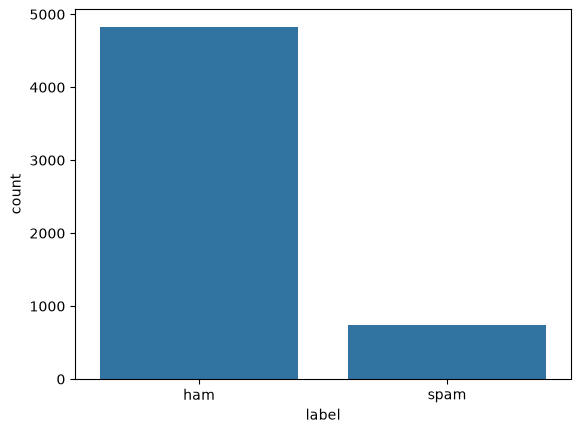

In [12]:
sns.countplot(data=df, x='label');

### Feature Engineering

In [13]:
len(df['text'][0])

111

In [14]:
df['length'] = df['text'].apply(len)

In [15]:
df

,label,text,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160
5568,ham,Will ü b going to esplanade fr home?,36
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


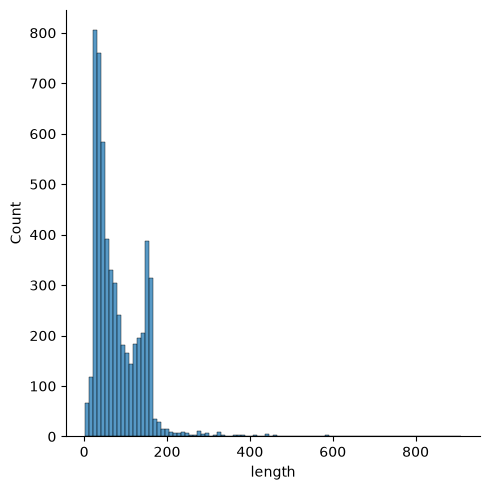

In [16]:
sns.displot(df['length']);

In [17]:
df['length'].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

In [18]:
df[df['length'] == 910]['text'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

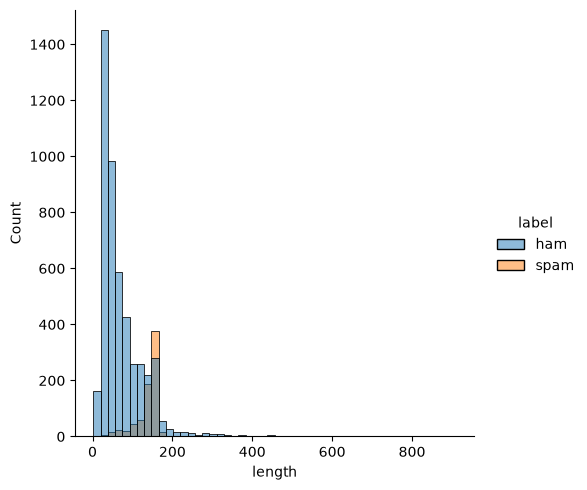

In [19]:
sns.displot(data=df,x='length', bins=50, hue="label");

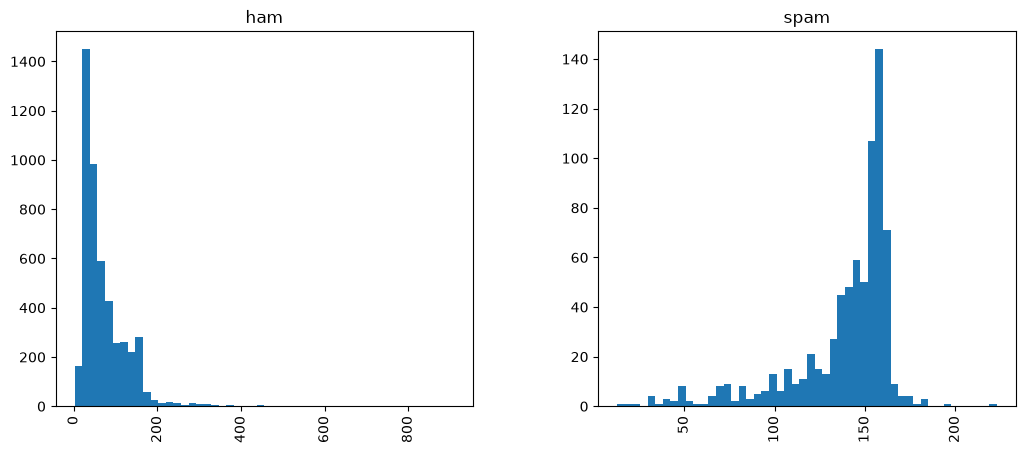

In [20]:
df.hist(column='length', by='label', bins=50, figsize=(12,5));

### Text Preprocessing

In [21]:
from nltk.corpus import stopwords
import string

In [22]:
stopwords.words('english')[1:20]

['about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been']

In [23]:
len(stopwords.words('english'))

198

In [24]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [25]:
# DRY (Dont Repeat Yourself); 2+ make a function

def text_processing(text):
    # remove punct
    remove_punc = [c for c in text if c not in string.punctuation]

    # Join punc together
    remove_punc = ''.join(remove_punc)

    # Remove stop words
    return [w for w in remove_punc.split() if w.lower() not in stopwords.words('english')]

In [26]:
df.head()

,label,text,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
df['text'].apply(text_processing)

0       [Go, jurong, point, crazy, Available, bugis, n...
1                          [Ok, lar, Joking, wif, u, oni]
2       [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3           [U, dun, say, early, hor, U, c, already, say]
4       [Nah, dont, think, goes, usf, lives, around, t...
                              ...                        
5567    [2nd, time, tried, 2, contact, u, U, £750, Pou...
5568                   [ü, b, going, esplanade, fr, home]
5569                     [Pity, mood, Soany, suggestions]
5570    [guy, bitching, acted, like, id, interested, b...
5571                                   [Rofl, true, name]
Name: text, Length: 5572, dtype: object

#### Vectorization

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [29]:
cv_transformer = CountVectorizer(analyzer=text_processing).fit(df['text'])

In [30]:
len(cv_transformer.vocabulary_)

11425

In [31]:
text_0 = df['text'][2]
text_0

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [32]:
bow_0 = cv_transformer.transform([text_0])

In [33]:
print(bow_0)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 21 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 73)	1
  (0, 423)	1
  (0, 430)	1
  (0, 443)	1
  (0, 871)	1
  (0, 1551)	1
  (0, 1833)	2
  (0, 1941)	1
  (0, 2804)	1
  (0, 3953)	1
  (0, 4731)	1
  (0, 5619)	1
  (0, 6331)	2
  (0, 6557)	1
  (0, 9159)	1
  (0, 9200)	1
  (0, 9252)	1
  (0, 10512)	1
  (0, 10686)	1
  (0, 11084)	1
  (0, 11123)	1


In [34]:
print(bow_0.shape)

(1, 11425)


In [35]:
cv_transformer.get_feature_names_out()[1833]

'FA'

In [36]:
cv_transformer.get_feature_names_out()[6331]

'entry'

In [37]:
text_messages_bow = cv_transformer.transform(df['text'])

In [38]:
print(f"Shape of the Sparse Matrix: {text_messages_bow.shape}")
print(f"Amount of Non-Zero Occurrances: {text_messages_bow.nnz}")

Shape of the Sparse Matrix: (5572, 11425)
Amount of Non-Zero Occurrances: 50548


In [39]:
sparcity = (text_messages_bow.nnz / (text_messages_bow.shape[0] * text_messages_bow.shape[1])) * 100

In [40]:
print(f"Sparcity: {sparcity}")

Sparcity: 0.07940295412668218


#### TF-IDF

##### Example

* Have 100 words
* bank mentioned 5 times
* TF: 5/100
* Assume 1M docs bank appears 1000 times
* IDF: log(1000000/1000) ~ 7
* TF-IDF: TF*IDF = 0.35

In [41]:
np.log(1000000/1000) * 0.05

np.float64(0.34538776394910686)

In [42]:
from sklearn.feature_extraction.text import TfidfTransformer

In [43]:
tfidf_transformer = TfidfTransformer().fit(text_messages_bow)

In [44]:
tfidf_0 = tfidf_transformer.transform(bow_0)

In [45]:
print(tfidf_0)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 73)	0.22538631044314436
  (0, 423)	0.09639170919810956
  (0, 430)	0.2177823443125605
  (0, 443)	0.2177823443125605
  (0, 871)	0.2118842499614227
  (0, 1551)	0.2177823443125605
  (0, 1833)	0.4507726208862887
  (0, 1941)	0.1526581729225716
  (0, 2804)	0.17524194104333074
  (0, 3953)	0.1544015632869991
  (0, 4731)	0.16452475271486866
  (0, 5619)	0.1887440015250524
  (0, 6331)	0.347904654589528
  (0, 6557)	0.18466951562322612
  (0, 9159)	0.22538631044314436
  (0, 9200)	0.22538631044314436
  (0, 9252)	0.16121646071144807
  (0, 10512)	0.2118842499614227
  (0, 10686)	0.13995540820792943
  (0, 11084)	0.15898145347176754
  (0, 11123)	0.19104387220509106


In [46]:
cv_transformer.get_feature_names_out()[423]

'2'

In [47]:
print(tfidf_transformer.idf_[cv_transformer.vocabulary_['think']])

4.863514852771781


In [48]:
text_tfidf = tfidf_transformer.transform(text_messages_bow)

In [49]:
text_tfidf.shape

(5572, 11425)

### NLP and Naive Bayes Model

#### Pipelines

In [50]:
from sklearn.naive_bayes import MultinomialNB

In [57]:
nb = MultinomialNB().fit(text_tfidf, df['label'])

In [58]:
print(tfidf_0[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 73)	0.22538631044314436
  (0, 423)	0.09639170919810956
  (0, 430)	0.2177823443125605
  (0, 443)	0.2177823443125605
  (0, 871)	0.2118842499614227
  (0, 1551)	0.2177823443125605
  (0, 1833)	0.4507726208862887
  (0, 1941)	0.1526581729225716
  (0, 2804)	0.17524194104333074
  (0, 3953)	0.1544015632869991
  (0, 4731)	0.16452475271486866
  (0, 5619)	0.1887440015250524
  (0, 6331)	0.347904654589528
  (0, 6557)	0.18466951562322612
  (0, 9159)	0.22538631044314436
  (0, 9200)	0.22538631044314436
  (0, 9252)	0.16121646071144807
  (0, 10512)	0.2118842499614227
  (0, 10686)	0.13995540820792943
  (0, 11084)	0.15898145347176754
  (0, 11123)	0.19104387220509106


In [59]:
text_0

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [60]:
pred = nb.predict(tfidf_0)[0]

In [61]:
expected = df['label'][2]

In [62]:
print(f"Predicted Value: {pred}\nExpected Value: {expected}")

Predicted Value: spam
Expected Value: spam


#### Model Evaluation

In [63]:
all_pred = nb.predict(text_tfidf)

In [64]:
all_pred

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'],
      shape=(5572,), dtype='<U4')

In [65]:
from sklearn.metrics import classification_report

In [66]:
print(classification_report(df['label'], all_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      4825
        spam       1.00      0.85      0.92       747

    accuracy                           0.98      5572
   macro avg       0.99      0.92      0.95      5572
weighted avg       0.98      0.98      0.98      5572



#### Oops, ran on everything
Lets do proper train-test split

In [67]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.33, random_state=42)

#### Pipeline

In [70]:
from sklearn.pipeline import Pipeline

In [72]:
pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_processing)),   # Strings to tokens
    ('tfidf', TfidfTransformer()), # TF-IDF scores
    ('classifier', MultinomialNB())  # Train model using TF-IDF with NB
])

In [73]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('bow', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U4](2,)","['ham','spam']"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",<function tex...002B3AD0749A0>
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


In [75]:
predictions = pipeline.predict(X_test)

In [76]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

         ham       1.00      0.96      0.98      1658
        spam       0.74      1.00      0.85       181

    accuracy                           0.96      1839
   macro avg       0.87      0.98      0.91      1839
weighted avg       0.97      0.96      0.97      1839

